###### Imports and Settings

In [585]:
import pandas as pd
import geopandas as gpd
import numpy as np
import requests
import io
import pickle
import matplotlib.pyplot as plt
from collections import deque
%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 150)

###### Functions

In [566]:
#function for percent of whole
def percent(x, y):
    try:
        return round((x/y)*100, 2)
    except ZeroDivisionError:
        return 666
#function for population density
def populationdensity(x, y):
    try:
        return round(x/y, 2)
    except ZeroDivisionError:
        return 666

# Project Introduction  

This notebook contains data preparation code for a peer communities analysis of the Nashville and Clarksville UZAs.

NOTES:  
I think veteran population would be good - considering services for veteran's and the strong presence in Clarksville UZA esp.  

Need to get Max and Ashleigh in early next week to talk about what we can do geographically...  


In [587]:
#to read in... rb is read bite
with open('api_keys.pkl', 'rb') as keys_file:
        keys_dict_2 = pickle.load(keys_file)

In [588]:
#create a variable that contains your api key
api_key = keys_dict_2['CENSUS']

## Read in DATAGUIDE

The "head" should never be more than 2 variables, and the "tail" never more than 2. Since we can pull 50 variables at once this means that we can systematically program in 46 variables for each pull, so that's:
+ dg1: ID's 1 - 46  
+ dg2: ID's 47-92  
+ dg3: ID's 93-138  
+ dg4: ID's 139-184

In [471]:
dataguide = pd.read_csv('../DATAGUIDE.csv', dtype = str)
dataguide['ID'] = dataguide['ID'].astype(int)

In [472]:
dg1 = dataguide[dataguide['ID'].between(1, 46)]
dg2 = dataguide[dataguide['ID'].between(47, 92)]

## Initial Call

In [595]:
# parameters
head = 'NAME'
tail_cols = 'GEOID'
#make variables list
var_list = list(dg1['ACS Variable'])
#add stuff to variables list
var_list = deque(var_list)
var_list.appendleft(head)
var_list = list(var_list)
#make columns list
col_list = list(dg1['Column Name'])
#add stuff to columns list
col_list.append(tail_cols)
col_list = deque(col_list)
col_list.appendleft(head)
col_list = list(col_list)
#API call
url_str= 'https://api.census.gov/data/2020/acs/acs5?key='+api_key
predicates= {}
get_vars= var_list
predicates["get"]= ",". join(get_vars)
predicates["for"]= "urban area:*"
data= requests.get(url_str, params= predicates)
col_names = col_list
initialcall=pd.DataFrame(columns=col_names, data=data.json()[1:])
print('Your API call is complete.')

Your API call is complete.


In [596]:
col_list

['NAME',
 'pop',
 'agebysex_total_series',
 'age_total_male',
 'age_m_u5',
 'age_m_5to9',
 'age_m_10to14',
 'age_m_15to17',
 'age_m_18to19',
 'age_m_20',
 'age_m_21',
 'age_m_22to24',
 'age_m_25to29',
 'age_m_30to34',
 'age_m_35to39',
 'age_m_40to44',
 'age_m_45to49',
 'age_m_50to54',
 'age_m_55to59',
 'age_m_60to61',
 'age_m_62to64',
 'age_m_65to66',
 'age_m_67to69',
 'age_m_70to74',
 'age_m_75to79',
 'age_m_80to84',
 'age_m_85+',
 'age_total_female',
 'age_f_u5',
 'age_f_5to9',
 'age_f_10to14',
 'age_f_15to17',
 'age_f_18to19',
 'age_f_20',
 'age_f_21',
 'age_f_22to24',
 'age_f_25to29',
 'age_f_30to34',
 'age_f_35to39',
 'age_f_40to44',
 'age_f_45to49',
 'age_f_50to54',
 'age_f_55to59',
 'age_f_60to61',
 'age_f_62to64',
 'age_f_65to66',
 'age_f_67to69',
 'GEOID']

In [597]:
var_list

['NAME',
 'B01001_001E',
 'B01001_001E',
 'B01001_002E',
 'B01001_003E',
 'B01001_004E',
 'B01001_005E',
 'B01001_006E',
 'B01001_007E',
 'B01001_008E',
 'B01001_009E',
 'B01001_010E',
 'B01001_011E',
 'B01001_012E',
 'B01001_013E',
 'B01001_014E',
 'B01001_015E',
 'B01001_016E',
 'B01001_017E',
 'B01001_018E',
 'B01001_019E',
 'B01001_020E',
 'B01001_021E',
 'B01001_022E',
 'B01001_023E',
 'B01001_024E',
 'B01001_025E',
 'B01001_026E',
 'B01001_027E',
 'B01001_028E',
 'B01001_029E',
 'B01001_030E',
 'B01001_031E',
 'B01001_032E',
 'B01001_033E',
 'B01001_034E',
 'B01001_035E',
 'B01001_036E',
 'B01001_037E',
 'B01001_038E',
 'B01001_039E',
 'B01001_040E',
 'B01001_041E',
 'B01001_042E',
 'B01001_043E',
 'B01001_044E',
 'B01001_045E']

## Final Call

In [504]:
head = 'NAME'
tail_cols = 'GEOID' #^ parameters
var_list = list(dg2['ACS Variable']) #^ make variables list
var_list = deque(var_list)
var_list.appendleft(head)
var_list = list(var_list) #^ add stuff to variables list
col_list = list(dg2['Column Name']) #^ make columns list
col_list.append(tail_cols)
col_list = deque(col_list)
col_list.appendleft(head)
col_list = list(col_list) #^ add stuff to columns list
url_str= 'https://api.census.gov/data/2020/acs/acs5?key='+api_key
predicates= {}
get_vars= var_list
predicates["get"]= ",". join(get_vars)
predicates["for"]= "urban area:*"
data= requests.get(url_str, params= predicates)
col_names = col_list
finalcall=pd.DataFrame(columns=col_names, data=data.json()[1:])
print('Your API call is complete.') #^ API call and initialize dataframe

Your API call is complete.


In [505]:
#enddrop = ['']
finalcall = finalcall.drop(columns = head)

In [506]:
data = initialcall.merge(finalcall, on = 'GEOID')

In [554]:
#column names to list, remove elements that don't need to be numeric dtypes and convert
numcols = list(data.columns)
numcols.remove('NAME')
numcols.remove('GEOID')
data[numcols] = data[numcols].astype(int)

In [578]:
data.columns

Index(['NAME', 'pop', 'agebysex_total_series', 'age_total_male', 'age_m_u5', 'age_m_5to9', 'age_m_10to14', 'age_m_15to17', 'age_m_18to19',
       'age_m_20', 'age_m_21', 'age_m_22to24', 'age_m_25to29', 'age_m_30to34', 'age_m_35to39', 'age_m_40to44', 'age_m_45to49', 'age_m_50to54',
       'age_m_55to59', 'age_m_60to61', 'age_m_62to64', 'age_m_65to66', 'age_m_67to69', 'age_m_70to74', 'age_m_75to79', 'age_m_80to84', 'age_m_85+',
       'age_total_female', 'age_f_u5', 'age_f_5to9', 'age_f_10to14', 'age_f_15to17', 'age_f_18to19', 'age_f_20', 'age_f_21', 'age_f_22to24',
       'age_f_25to29', 'age_f_30to34', 'age_f_35to39', 'age_f_40to44', 'age_f_45to49', 'age_f_50to54', 'age_f_55to59', 'age_f_60to61',
       'age_f_62to64', 'age_f_65to66', 'age_f_67to69', 'GEOID', 'age_f_70to74', 'age_f_75to79', 'age_f_80to84', 'age_f_85+',
       'disability_series_total', 'disability_total_male', 'disability_mu5', 'disability_mu5_nodisability', 'disability_mu5_wdisability',
       'disability_m5to17', 'di

# Calculations

## Senior Population  
+ 55+  
+ 65+  
Number and Percent

In [571]:
list55older = [data['age_m_55to59'],data['age_m_60to61'],data['age_m_62to64'],data['age_m_65to66'],data['age_m_67to69'],data['age_m_70to74'],data['age_m_75to79'],
               data['age_m_80to84'],data['age_m_85+'],data['age_f_55to59'],data['age_f_60to61'],data['age_f_62to64'],data['age_f_65to66'],data['age_f_67to69'],
               data['age_f_70to74'],data['age_f_75to79'],data['age_f_80to84'],data['age_f_85+']]
data['popage_55+'] = 0
for num in list55older:
    data['popage_55+'] = data['age_55+']+num
list65older = [data['age_m_65to66'],data['age_m_67to69'],data['age_m_70to74'],data['age_m_75to79'],data['age_m_80to84'],data['age_m_85+'],data['age_f_65to66'],
               data['age_f_67to69'],data['age_f_70to74'],data['age_f_75to79'],data['age_f_80to84'],data['age_f_85+']]
data['popage_65+'] = 0
for num in list65older:
    data['popage_65+'] = data['age_65+']+num

In [574]:
data['pop%age_55+'] = percent(data['popage_55+'], data['agebysex_total_series'])
data['pop%age_65+'] = percent(data['popage_65+'], data['agebysex_total_series'])

In [580]:
data = data.drop(columns =['agebysex_total_series','age_total_male','age_m_u5','age_m_5to9','age_m_10to14','age_m_15to17','age_m_18to19',
       'age_m_20','age_m_21','age_m_22to24','age_m_25to29','age_m_30to34','age_m_35to39','age_m_40to44','age_m_45to49','age_m_50to54',
       'age_m_55to59','age_m_60to61','age_m_62to64','age_m_65to66','age_m_67to69','age_m_70to74','age_m_75to79','age_m_80to84','age_m_85+',
       'age_total_female','age_f_u5','age_f_5to9','age_f_10to14','age_f_15to17','age_f_18to19','age_f_20','age_f_21','age_f_22to24',
       'age_f_25to29','age_f_30to34','age_f_35to39','age_f_40to44','age_f_45to49','age_f_50to54','age_f_55to59','age_f_60to61',
       'age_f_62to64','age_f_65to66','age_f_67to69','GEOID','age_f_70to74','age_f_75to79','age_f_80to84','age_f_85+'])

In [581]:
data.head()

,NAME,pop,disability_series_total,disability_total_male,disability_mu5,disability_mu5_nodisability,disability_mu5_wdisability,disability_m5to17,disability_m5to17_nodisability,disability_m5to17_wdisability,disability_m18to34,disability_m18to34_nodisability,disability_m18to34_wdisability,disability_m35to64,disability_m35to64_nodisability,disability_m35to64_wdisability,disability_m65to74,disability_m65to74_nodisability,disability_m65to74_wdisability,disability_m75+,disability_m75+_nodisability,disability_m75+_wdisability,disability_total_female,disability_fu5,disability_fu5_nodisability,disability_fu5_wdisability,disability_f5to17,disability_f5to17_nodisability,disability_f5to17_wdisability,disability_f18to34,disability_f18to34_nodisability,disability_f18to34_wdisability,disability_f35to64,disability_f35to64_nodisability,disability_f35to64_wdisability,disability_f65to74,disability_f65to74_nodisability,disability_f65to74_wdisability,disability_f75+,disability_f75+_nodisability,disability_f75+_wdisability,age_55+,age_65+,popage_55+,popage_65+,pop%age_55+,pop%age_65+
0,"Spring Creek South, NV Urban Cluster (2010)",4404,4396,2425,140,0,140,843,48,795,448,66,382,775,238,537,106,28,78,113,85,28,1971,116,0,116,461,0,461,473,13,460,719,63,656,92,14,78,110,100,10,1650,842,1650,842,37.47,19.12
1,"Mannford, OK Urban Cluster (2010)",3041,2973,1424,111,0,111,381,23,358,298,18,280,482,69,413,60,16,44,92,36,56,1549,102,0,102,298,4,294,431,17,414,485,62,423,122,26,96,111,49,62,1548,884,1600,936,52.61,30.78
2,"Manning, SC Urban Cluster (2010)",4869,4818,1997,74,0,74,379,45,334,467,67,400,581,244,337,191,54,137,305,219,86,2821,151,0,151,578,26,552,564,30,534,705,173,532,454,192,262,369,316,53,3420,2638,3643,2861,74.82,58.76
3,"Manor, TX Urban Cluster (2010)",10981,10960,5335,699,0,699,1538,138,1400,879,0,879,2050,177,1873,128,40,88,41,11,30,5625,1094,0,1094,1309,73,1236,1203,0,1203,1797,72,1725,181,86,95,41,41,0,2286,782,2296,792,20.91,7.21
4,"Mansfield, LA Urban Cluster (2010)",6077,5902,2729,220,0,220,404,100,304,677,1,676,1033,350,683,239,155,84,156,88,68,3173,225,32,193,470,41,429,726,107,619,1139,331,808,241,88,153,372,99,273,3312,2134,3378,2200,55.59,36.20


# GEO Data

In [589]:
url= 'https://www2.census.gov/geo/tiger/TIGER2021/UAC/tl_2021_us_uac10.zip'
geo = gpd.read_file(url)
print('Your geographic file is ready.')

Your geographic file is ready.


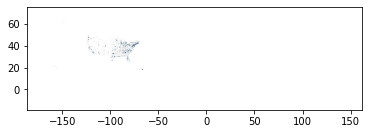

In [590]:
geo.plot();

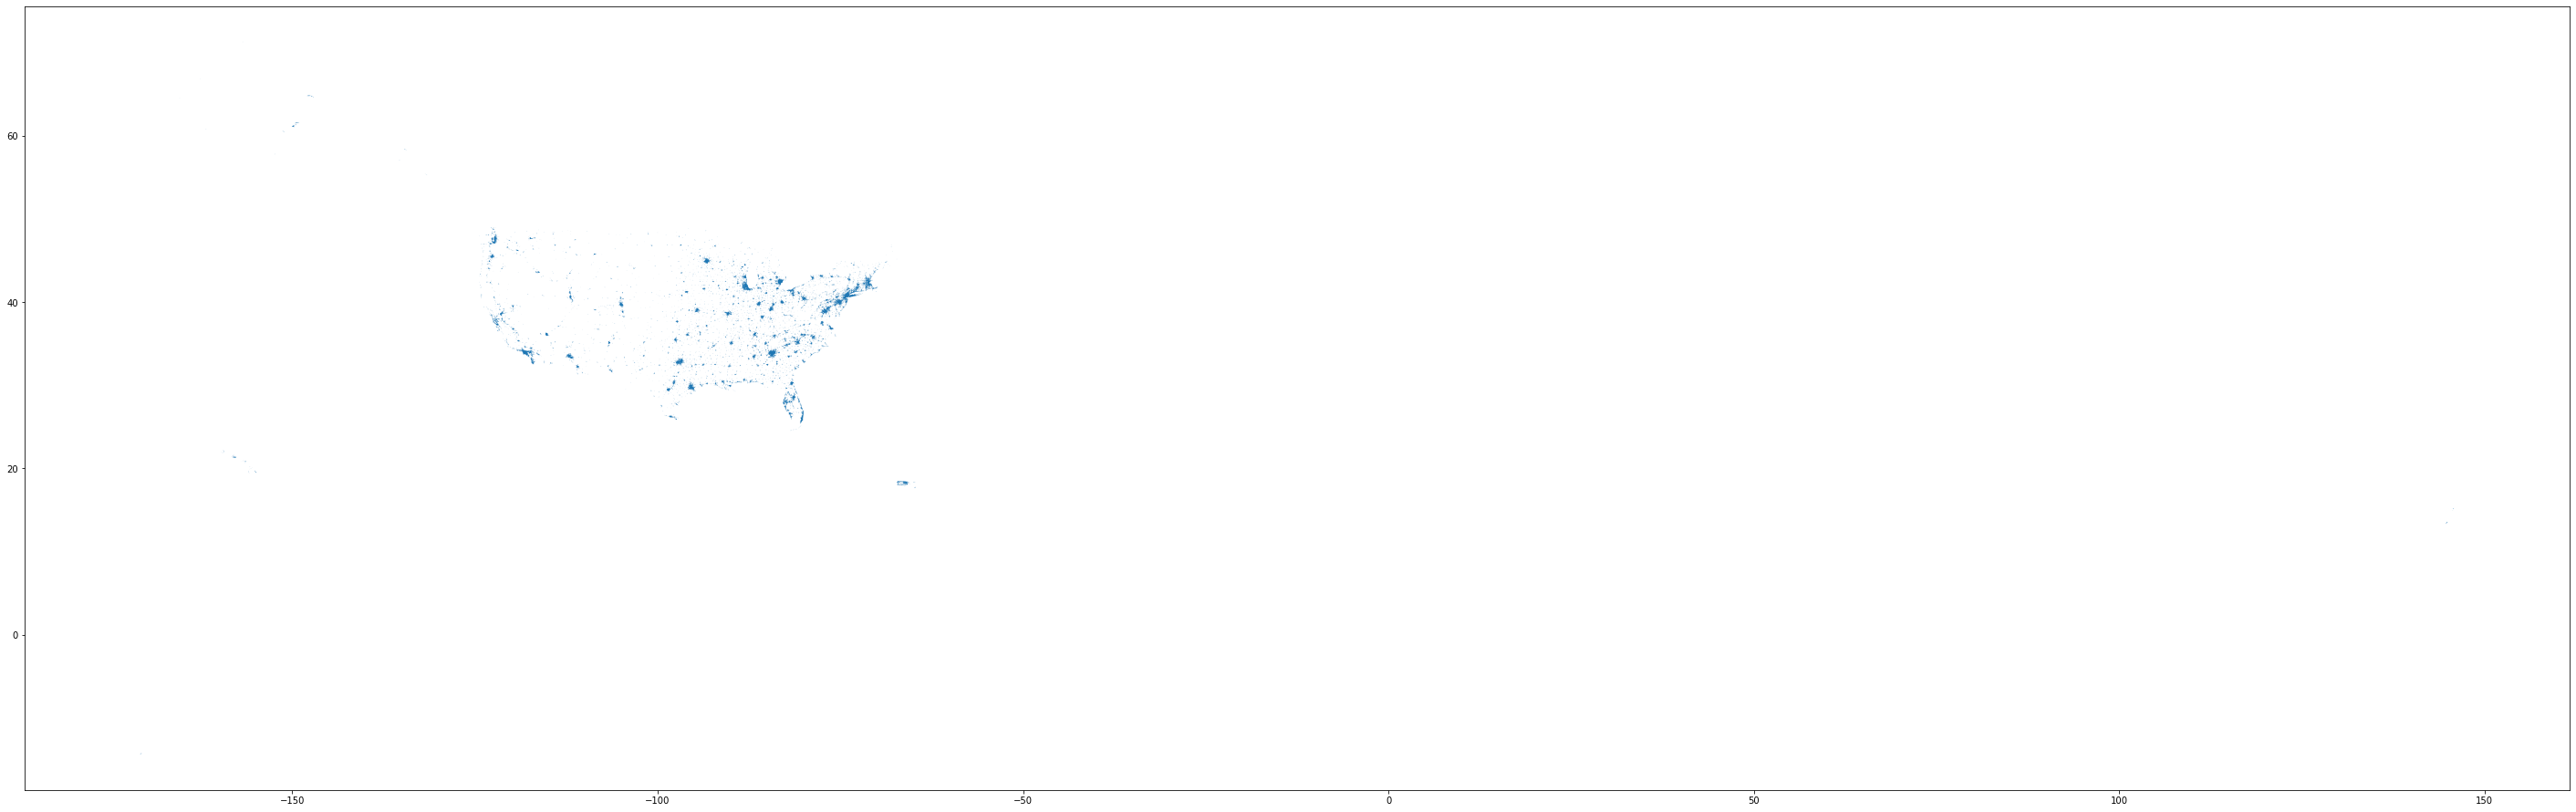

In [594]:
fig, ax = plt.subplots(figsize=(50,50))
geo.plot(ax = ax);

In [524]:
#isolate the urban areas, don't need the clusters now
geo = geo.loc[geo['UATYP10'] == 'U']

In [525]:
geo = geo.drop(columns = ['GEOID10','NAMELSAD10','LSAD10','MTFCC10','UATYP10','FUNCSTAT10','INTPTLAT10','INTPTLON10','AWATER10'])

Get square miles - this unit is square meters so we will divide the value by 2589988.1103

In [527]:
conversionfactor = 2589988.1103

In [530]:
geo['SQMILES'] = geo['ALAND10']/conversionfactor
geo = geo.drop(columns = ['ALAND10'])

In [532]:
geo = geo.rename(columns = {'UACE10':'GEOID','NAME10':'NAME'})